# Mouth-region alignment from calcium imaging video and DLC tracking

This code aligns the Hydra mouth region using DeepLabCut tracking coordinates.

Input:

1. A calcium imaging video file (`.avi`)
2. A DeepLabCut `.csv` file containing mouth and head landmark coordinates

What the code does:

1. Uploads the calcium imaging video and DLC coordinate file in Google Colab.
2. Reads the mouth tip and left/right head landmark positions.
3. Rotates each video frame using the mouth-to-head-center vector.
4. Crops a 30 × 30 pixel region centered on the mouth.
5. Applies a circular mask around the mouth region.
6. Writes a black frame if tracking coordinates are missing or the crop is outside the image.
7. Saves the aligned mouth-region movie as an MJPG `.avi` file.
8. Displays example frames for visual inspection.

Output:
A file named:

`original_video_name_aligned.avi`

Notes:
This script was used for mouth-region alignment in the analysis for Figure 4 and Figure S7. The aligned movie allows calcium activity around the mouth to be compared across time after correcting for animal movement and orientation. The default crop is 30 × 30 pixels, centered on the tracked mouth point. Tracking accuracy should be visually checked.


Step 1: Manual Upload of Video and DLC .csv File

In [ ]:
# STEP 1: Upload video and DeepLabCut .csv
from google.colab import files
import cv2
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm
import os

# Upload files
print("Upload your calcium imaging video (.avi):")
uploaded_video = files.upload()

print("Upload your DeepLabCut CSV file:")
uploaded_csv = files.upload()

# Get filenames
video_filename = list(uploaded_video.keys())[0]
csv_filename = list(uploaded_csv.keys())[0]


Upload your calcium imaging video (.avi):


Saving 01 a RP2 1.6x2.5 f11269-11441.avi to 01 a RP2 1.6x2.5 f11269-11441.avi
Upload your DeepLabCut CSV file:


Saving 01 a RP2 1.6x2.5 f11269-11441DLC_resnet50_01 a RP2 1.6x2.5 f11269-11441Apr16shuffle1_10000.csv to 01 a RP2 1.6x2.5 f11269-11441DLC_resnet50_01 a RP2 1.6x2.5 f11269-11441Apr16shuffle1_10000.csv


In [ ]:
# STEP 2: Read DeepLabCut data (only skip 2 rows)
df = pd.read_csv(csv_filename, skiprows=2)

# Extract coordinates
x_a = df.iloc[:, 1].astype(float).values  # mouth tip x
y_a = df.iloc[:, 2].astype(float).values  # mouth tip y
x_b = df.iloc[:, 4].astype(float).values  # left head x
y_b = df.iloc[:, 5].astype(float).values  # left head y
x_c = df.iloc[:, 7].astype(float).values  # right head x
y_c = df.iloc[:, 8].astype(float).values  # right head y

# STEP 3: Load video and prepare writer
cap = cv2.VideoCapture(video_filename)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

In [ ]:
# Set output video size and name
circle_radius = 15
output_size = circle_radius * 2  # 30x30
output_filename = os.path.splitext(video_filename)[0] + "_aligned.avi"
fourcc = cv2.VideoWriter_fourcc(*'MJPG')  # more widely supported format
out = cv2.VideoWriter(output_filename, fourcc, fps, (output_size, output_size), isColor=False)

# STEP 4: Create circular mask
def create_circular_mask(radius):
    size = radius * 2
    Y, X = np.ogrid[:size, :size]
    dist = np.sqrt((X - radius)**2 + (Y - radius)**2)
    mask = dist <= radius
    return mask.astype(np.uint8)

circle_mask = create_circular_mask(circle_radius)

In [ ]:
# STEP 5: Process and align each frame
print("Processing and aligning video...")
for i in tqdm(range(min(len(x_a), frame_count))):
    ret, frame = cap.read()
    if not ret:
        break

    # Convert to grayscale
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Coordinates
    cx, cy = x_a[i], y_a[i]
    if np.isnan([cx, cy, x_b[i], y_b[i], x_c[i], y_c[i]]).any():
        out.write(np.zeros((output_size, output_size), dtype=np.uint8))  # fallback black
        continue

    # Vector from mouth to midpoint between left/right head
    head_center_x = (x_b[i] + x_c[i]) / 2
    head_center_y = (y_b[i] + y_c[i]) / 2

    dx = head_center_x - cx
    dy = head_center_y - cy
    angle = np.arctan2(dy, dx) * 180 / np.pi - 90  # rotate to face upward


    # Rotate image around mouth tip
    M = cv2.getRotationMatrix2D((cx, cy), angle, 1.0)
    rotated = cv2.warpAffine(gray, M, (frame_width, frame_height), flags=cv2.INTER_LINEAR)

    # Crop square region centered on mouth
    x_start = int(cx - circle_radius)
    y_start = int(cy - circle_radius)
    x_end = x_start + output_size
    y_end = y_start + output_size

    # Boundary check
    if x_start < 0 or y_start < 0 or x_end > frame_width or y_end > frame_height:
        out.write(np.zeros((output_size, output_size), dtype=np.uint8))
        continue

    cropped = rotated[y_start:y_end, x_start:x_end]

    # Apply circular mask
    masked = cropped * circle_mask

    # Final shape check
    if masked.shape != (output_size, output_size):
        masked = np.zeros((output_size, output_size), dtype=np.uint8)

    out.write(masked.astype(np.uint8))



Processing and aligning video...


100%|██████████| 173/173 [00:01<00:00, 157.72it/s]



✅ Done! Saved aligned video as: 01 a RP2 1.6x2.5 f11269-11441_aligned.avi
Displaying example frames for visual check:


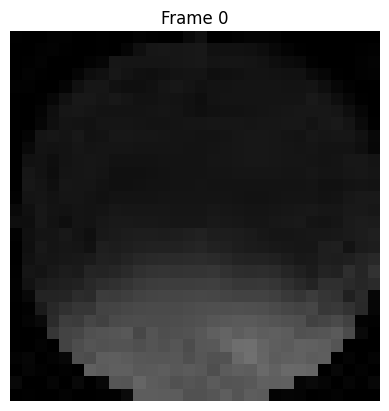

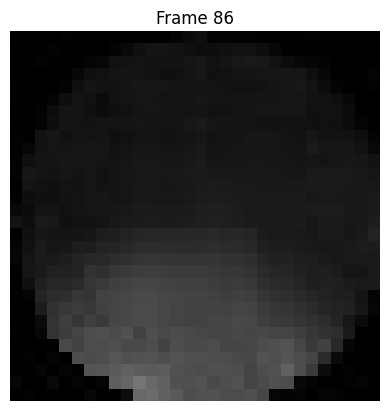

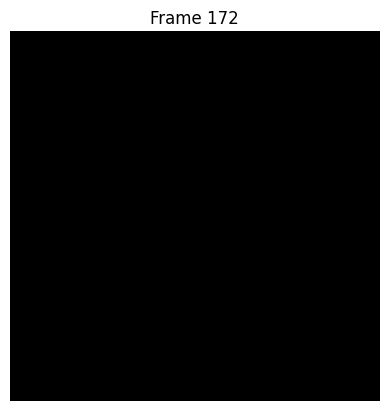

In [ ]:
# Finalize video
cap.release()
out.release()
print(f"\n✅ Done! Saved aligned video as: {output_filename}")

# Show example aligned frames
print("Displaying example frames for visual check:")

import matplotlib.pyplot as plt

def show_frame(title, frame_array):
    plt.figure()
    plt.imshow(frame_array, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

# Reload video and extract 3 key frames
cap_check = cv2.VideoCapture(output_filename)
frame_total = int(cap_check.get(cv2.CAP_PROP_FRAME_COUNT))

check_indices = [0, frame_total // 2, frame_total - 1]
frames_to_show = []

for i in range(frame_total):
    ret, frame = cap_check.read()
    if not ret:
        break
    if i in check_indices:
        frames_to_show.append((i, frame.copy()))

cap_check.release()

# Show the selected frames
for idx, frame in frames_to_show:
    show_frame(f"Frame {idx}", frame)

In [ ]:
from google.colab import files
files.download(output_filename)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Parameters you can tweak
Parameter	Description	Default
circle_radius	Crop/mask radius around mouth tip (in px)	15
angle calc	Direction is from point b (left) to point c (right). If this looks off, reverse the two
crop region	Square size = circle_radius × 2	30×30
mask shape	Circle — can make square for debugging